In [1]:
import pickle

with open("stats/crowded_ultimate.pkl", "rb") as f:
    crowded = pickle.load(f)

with open("stats/daytime_ultimate.pkl", "rb") as f:
    daytime = pickle.load(f)

with open("stats/weather_ultimate.pkl", "rb") as f:
    weather = pickle.load(f)

with open("stats/indoor_outdoor_ultimate.pkl", "rb") as f:
    indoor_outdoor = pickle.load(f)

print('CROWDED')
crowded_total = len(crowded[0]) + len(crowded[1]) + len(crowded[2]) + len(crowded[3]) 
print("EMPTY", len(crowded[0])/crowded_total)
print("SCATERED", len(crowded[1])/crowded_total)
print("MODERATE", len(crowded[2])/crowded_total)
print("CROWDED",len(crowded[3])/crowded_total)

print('DAYTIME')
daytime_total = len(daytime[0]) + len(daytime[1]) 
print("DAY", len(daytime[0])/daytime_total)
print("NIGHT", len(daytime[1])/daytime_total)

print('INDOOR_OUTDOOR')
indoor_outdoor_total = len(indoor_outdoor[0]) + len(indoor_outdoor[1]) 
print("INDOOR", len(indoor_outdoor[0])/indoor_outdoor_total)
print("OUTDOOR", len(indoor_outdoor[1])/indoor_outdoor_total)


print('WEATHER')
weather_total = len(weather[0]) + len(weather[1])+ len(weather[2])+ len(weather[3]) 
print("SUNNY", len(weather[0])/weather_total)
print("RAINY", len(weather[1])/weather_total)
print("CLOUDY", len(weather[2])/weather_total)
print("SNOWY", len(weather[3])/weather_total)

CROWDED
EMPTY 0.14479025710419485
SCATERED 0.4225304465493911
MODERATE 0.3688261163734777
CROWDED 0.0638531799729364
DAYTIME
DAY 0.836180649526387
NIGHT 0.16381935047361298
INDOOR_OUTDOOR
INDOOR 0.11713464140730717
OUTDOOR 0.8828653585926928
WEATHER
SUNNY 0.5378044654939107
RAINY 0.07307171853856563
CLOUDY 0.3499661705006766
SNOWY 0.039157645466847094


In [2]:
country_to_region_globe = {
    "United Kingdom": "Anglo",
    "Belgium": "Germanic Europe",
    "Ireland": "Anglo",
    "France": "Latin Europe",
    "Germany": "Germanic Europe",
    "Portugal": "Latin Europe",
    "Spain": "Latin Europe",
    "Italy": "Latin Europe",
    "Switzerland": "Latin Europe",
    "Netherlands": "Germanic Europe",
    "Austria": "Germanic Europe",
    "Malta": "Latin Europe",
    "Denmark": "Nordic Europe",
    "Norway": "Nordic Europe",
    "Sweden": "Nordic Europe",
    "Finland": "Nordic Europe",
    "Iceland": "Nordic Europe",
    "Greece": "Eastern Europe",
    "Poland": "Eastern Europe",
    "Czech Republic": "Eastern Europe",
    "Slovakia": "Eastern Europe",
    "Hungary": "Eastern Europe",
    "Romania": "Latin Europe",
    "Belarus": "Eastern Europe",
    "Serbia": "Eastern Europe",
    "Moldova": "Latin Europe",
    "Estonia": "Nordic Europe",
    "Latvia": "Nordic Europe",
    "United States": "Anglo",
    "Canada": "Anglo",
    "Bermuda": "Other",
    "Mexico": "Latin America",
    "Brazil": "Latin America",
    "Chile": "Latin America",
    "Peru": "Latin America",
    "Uruguay": "Latin America",
    "Paraguay": "Latin America",
    "Colombia": "Latin America",
    "Costa Rica": "Latin America",
    "Venezuela": "Latin America",
    "Jamaica": "African",
    "Barbados": "African",
    "Antigua and Barbuda": "African",
    "Saint Lucia": "Other",
    "Kenya": "African",
    "Malawi": "African",
    "South African": "African",
    "Nigeria": "African",
    "Ghana": "African",
    "Senegal": "African",
    "Benin": "African",
    "Madagascar": "African",
    "Ethiopia": "African",
    "Eritrea": "African",
    "Mali": "African",
    "Gambia": "African",
    "United Arab Emirates": "Middle East",
    "Jordan": "Middle East",
    "Syria": "Middle East",
    "Iraq": "Middle East",
    "Lebanon": "Middle East",
    "Egypt": "Middle East",
    "Morocco": "Middle East",
    "Kuwait": "Middle East",
    "Israel": "Latin Europe",
    "Turkey": "Middle East",
    "Afghanistan": "South-East Asia",
    "India": "South-East Asia",
    "Pakistan": "South-East Asia",
    "Bangladesh": "South-East Asia",
    "Sri Lanka": "South-East Asia",
    "Nepal": "South-East Asia",
    "China": "Confucian Asia",
    "Japan": "Confucian Asia",
    "South Korea": "Confucian Asia",
    "Taiwan": "Confucian Asia",
    "Thailand": "South-East Asia",
    "Vietnam": "Confucian Asia",
    "Indonesia": "South-East Asia",
    "Singapore": "Confucian Asia",
    "Brunei": "South-East Asia",
    "Kazakhstan": "Eastern Europe",
    "Kyrgyzstan": "Eastern Europe",
    "Tajikistan": "South-East Asia",
    "Azerbaijan": "Middle East",
    "Georgia": "Eastern Europe",
    "Australia": "Anglo",
    "New Zealand": "Anglo",
    "Samoa": "South-East Asia",
    "Holy See": "Other",
    "South Africa": "African"
}

In [14]:
import glob
import matplotlib.pyplot as plt
import json
import cv2
import numpy as np
from collections import defaultdict

path = 'SEKAI_720_3/videos_frames'

files = glob.glob(f'{path}/*')

#print(files)
countries = defaultdict(int)
cities = defaultdict(int)
origin = []


sekai, ours = 0, 0

country_mapping = {
    "USA": "United States",
    "UAE": "United Arab Emirates",
    "Korea": "South Korea",
    "Czechia": "Czech Republic",
}

regions_to_clip_ids = defaultdict(list)

for file_id, file in enumerate(files):
    path = file.split('/')[-1]
    with open(f'{file.replace('videos_frames','jsons_step1')}.json', 'r') as f:
        data = json.load(f)
    
    country = data['country']
    city = data['city']
    origin.append(data['source'])
    if data['dataset'] == 'sekai':
        sekai+=1
    else:
        ours+=1

    if country in country_mapping.keys():
        country = country_mapping[country]

    regions_to_clip_ids[country_to_region_globe[country]].append(file_id + (180 if file_id > 180 else 0))
    
    cities[data['city']]+=1
    countries[country]+=1


print('Number of countries:', len(countries))
print('Number of cities:', len(cities))


print(sekai)
print(ours)

print('Sekai (%)', sekai/(sekai+ours))
print('Number of clips (Sekai):', sekai)

print('Ours (%)', ours/(sekai+ours))
print('Number of clips (Ours):', ours)


print('')
print('Region to clip IDs:')
print(regions_to_clip_ids)

Number of countries: 75
Number of cities: 153
511
209
Sekai (%) 0.7097222222222223
Number of clips (Sekai): 511
Ours (%) 0.2902777777777778
Number of clips (Ours): 209

Region to clip IDs:
defaultdict(<class 'list'>, {'Anglo': [0, 4, 7, 11, 20, 21, 22, 35, 39, 43, 47, 51, 53, 55, 59, 61, 65, 72, 87, 90, 92, 99, 107, 113, 120, 126, 130, 142, 146, 150, 153, 154, 157, 162, 168, 175, 176, 177, 179, 362, 363, 366, 381, 387, 389, 390, 393, 396, 400, 401, 407, 410, 416, 421, 433, 436, 437, 443, 444, 448, 455, 457, 465, 466, 468, 474, 477, 481, 485, 494, 505, 513, 524, 531, 535, 539, 549, 551, 552, 563, 573, 574, 577, 579, 581, 583, 588, 589, 593, 596, 599, 601, 608, 610, 612, 621, 623, 626, 631, 633, 643, 648, 653, 654, 658, 661, 662, 666, 667, 674, 676, 686, 689, 692, 694, 700, 703, 706, 707, 711, 713, 718, 719, 722, 724, 730, 733, 736, 744, 745, 747, 750, 757, 761, 764, 770, 772, 773, 776, 777, 778, 780, 784, 785, 796, 813, 817, 820, 822, 828, 830, 843, 846, 854, 855, 857, 858, 874, 887, 89

{'United Kingdom': 89, 'United States': 54, 'United Arab Emirates': 47, 'Japan': 44, 'China': 40, 'Germany': 30, 'South Korea': 23, 'Italy': 20, 'Portugal': 19, 'Kenya': 18, 'Pakistan': 16, 'France': 14, 'Chile': 14, 'Poland': 13, 'Thailand': 13, 'Switzerland': 12, 'Nepal': 11, 'Indonesia': 10, 'Peru': 10, 'Finland': 10, 'Brazil': 10, 'Estonia': 9, 'Egypt': 8, 'Canada': 8, 'Norway': 7, 'Uruguay': 7, 'Ethiopia': 7, 'Costa Rica': 7, 'Afghanistan': 7, 'Latvia': 7, 'Nigeria': 7, 'Iraq': 7, 'New Zealand': 6, 'Holy See': 6, 'Colombia': 6, 'Taiwan': 6, 'Kuwait': 6, 'Belarus': 6, 'Morocco': 6, 'Azerbaijan': 5, 'Hungary': 4, 'Mexico': 4, 'Barbados': 4, 'Jordan': 4, 'Singapore': 4, 'Jamaica': 3, 'Iceland': 3, 'Greece': 3, 'Belgium': 3, 'Malta': 3, 'Australia': 3, 'Kyrgyzstan': 3, 'Georgia': 3, 'Spain': 2, 'Sri Lanka': 2, 'Israel': 2, 'Tajikistan': 2, 'Czech Republic': 2, 'Ireland': 2, 'Gambia': 2, 'Saint Lucia': 2, 'Syria': 2, 'Sweden': 1, 'Benin': 1, 'Eritrea': 1, 'Venezuela': 1, 'Vietnam': 1, 

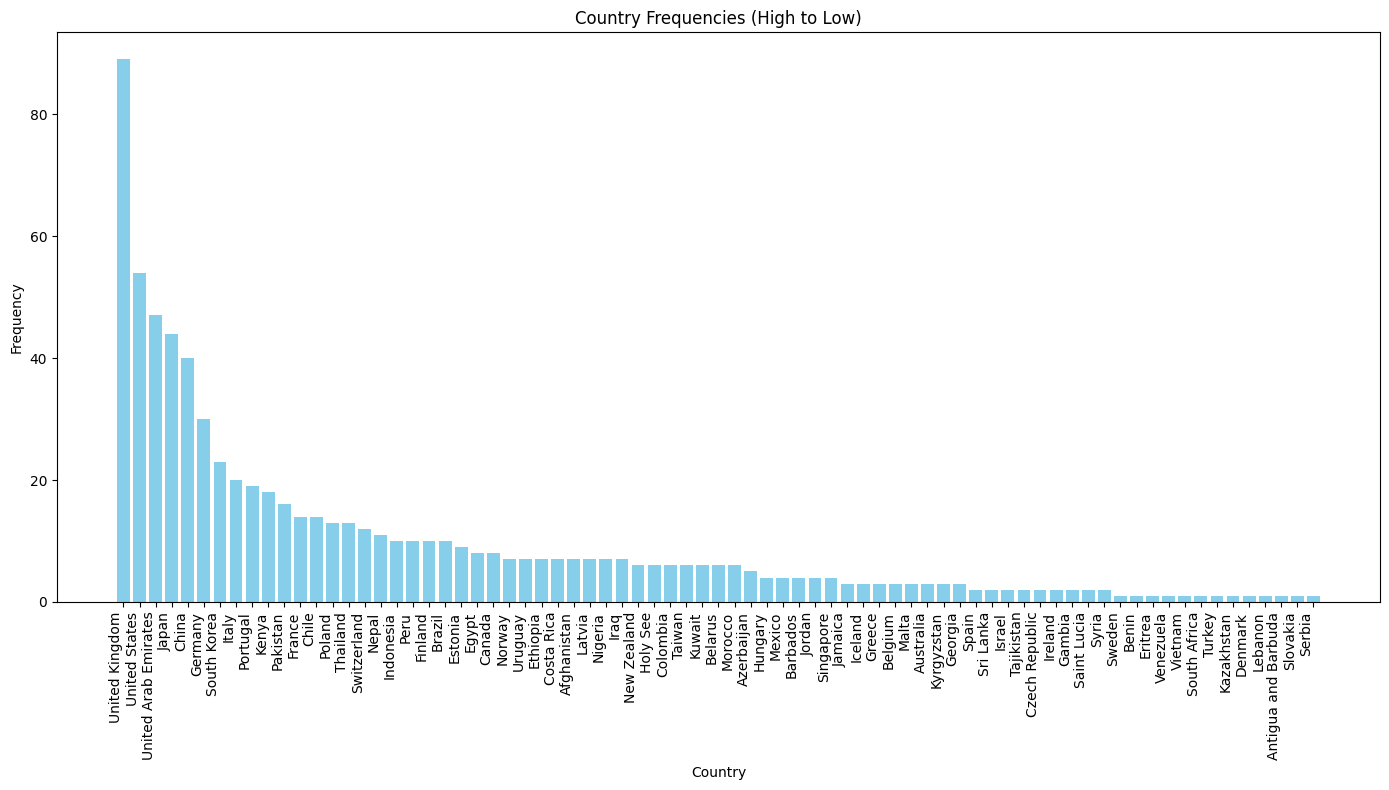

In [15]:
#print(countries)

sorted_data = dict(sorted(countries.items(), key=lambda item: item[1], reverse=True))

print(sorted_data)
# Step 3: Plot
plt.figure(figsize=(14, 8))
plt.bar(sorted_data.keys(), sorted_data.values(), color='skyblue')
plt.xticks(rotation=90, ha='right')
plt.xlabel("Country")
plt.ylabel("Frequency")
plt.title("Country Frequencies (High to Low)")
plt.tight_layout()
plt.show()

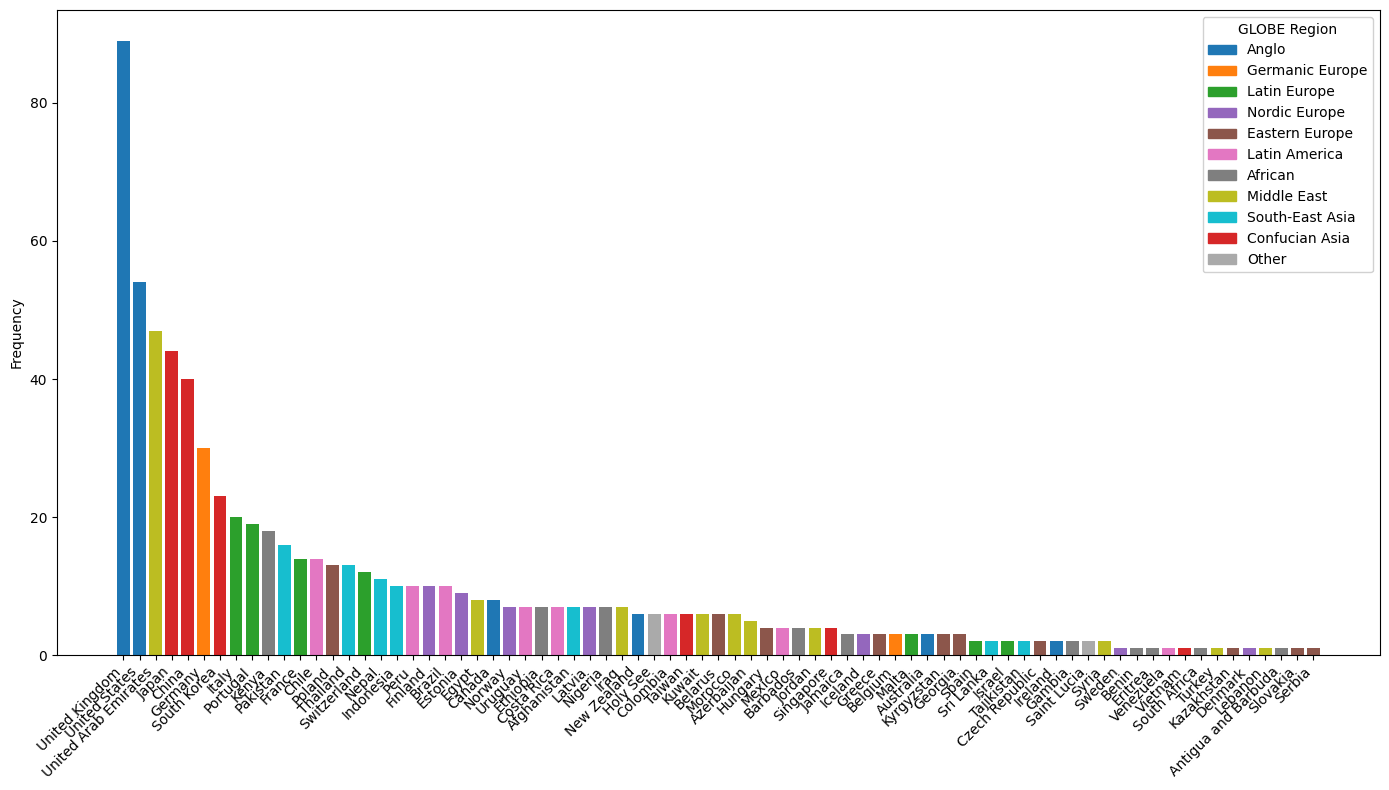

In [16]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Sort countries by frequency
sorted_data = dict(sorted(countries.items(), key=lambda item: item[1], reverse=True))

# Region → color mapping
region_colors = {
    "Anglo": "#1f77b4",
    "Germanic Europe": "#ff7f0e",
    "Latin Europe": "#2ca02c",
    "Nordic Europe": "#9467bd",
    "Eastern Europe": "#8c564b",
    "Latin America": "#e377c2",
    "African": "#7f7f7f",
    "Middle East": "#bcbd22",
    "South-East Asia": "#17becf",
    "Confucian Asia": "#d62728",
    "Other": "#aaaaaa"
}

# Create color list aligned with sorted countries
bar_colors = [
    region_colors.get(country_to_region_globe.get(country, "Other"), "#aaaaaa")
    for country in sorted_data.keys()
]

# Plot
plt.figure(figsize=(14, 8))
plt.bar(sorted_data.keys(), sorted_data.values(), color=bar_colors)

plt.xticks(rotation=45, ha='right')
#plt.xlabel("Country")
plt.ylabel("Frequency")
#plt.title("Country Frequencies Colored by GLOBE Cultural Region")

legend_handles = [
    mpatches.Patch(color=color, label=region)
    for region, color in region_colors.items()
]

plt.legend(
    handles=legend_handles,
    title="GLOBE Region",
    loc="upper right",
    framealpha=0.9
)

plt.savefig(
    "country_frequencies.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

{'Anglo': 162, 'Confucian Asia': 118, 'Middle East': 87, 'Latin Europe': 72, 'South-East Asia': 61, 'Latin America': 59, 'African': 45, 'Nordic Europe': 38, 'Eastern Europe': 37, 'Germanic Europe': 33, 'Other': 8}


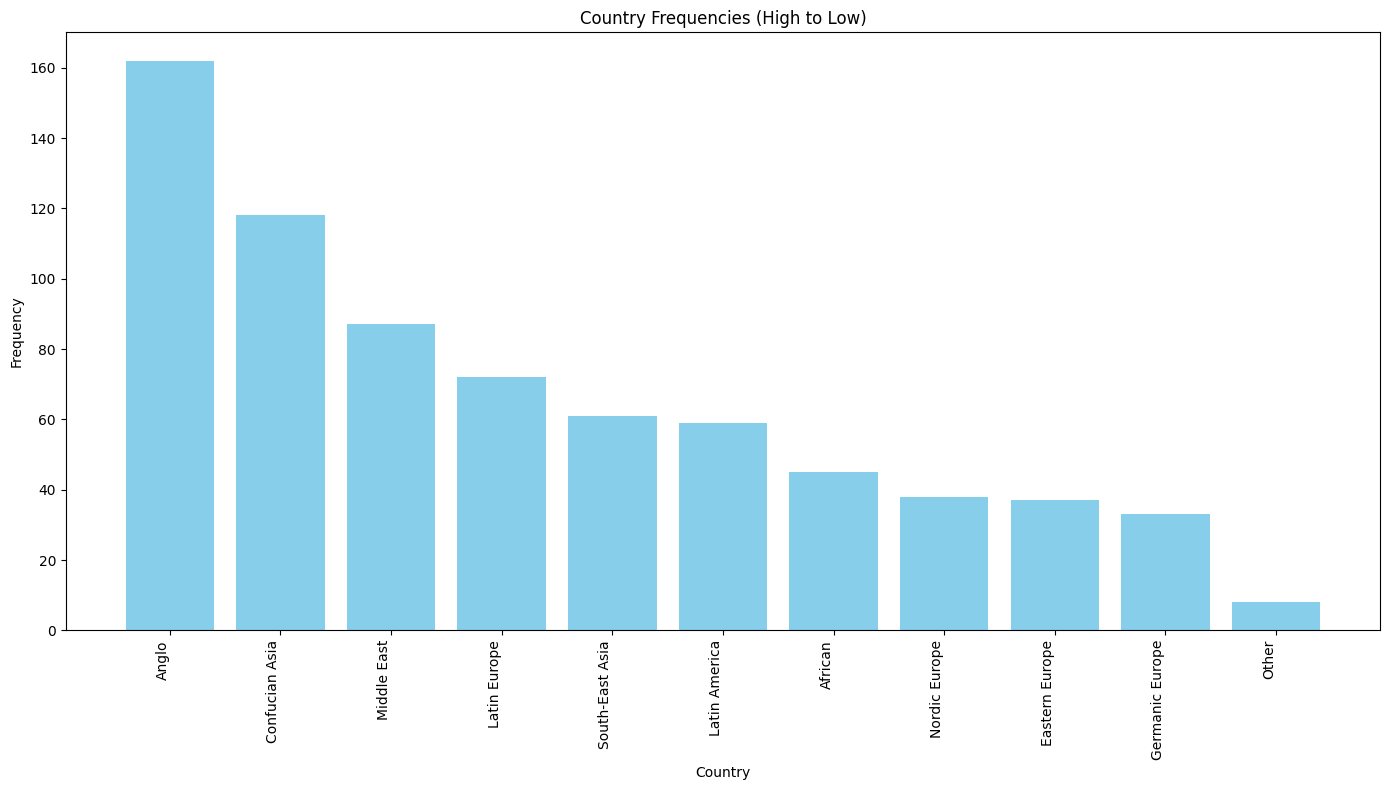

In [17]:
regions = defaultdict(int)
#print(countries)
for country in countries:
    regions[country_to_region_globe[country]]+=countries[country]
    
sorted_data = dict(sorted(regions.items(), key=lambda item: item[1], reverse=True))

print(sorted_data)
# Step 3: Plot
plt.figure(figsize=(14, 8))
plt.bar(sorted_data.keys(), sorted_data.values(), color='skyblue')
plt.xticks(rotation=90, ha='right')
plt.xlabel("Country")
plt.ylabel("Frequency")
plt.title("Country Frequencies (High to Low)")
plt.tight_layout()
plt.show()

In [18]:
import statistics
total = sum(sorted_data.values())

# Percentages
percentages = {k: (v / total) * 100 for k, v in sorted_data.items()}

# Mean and median
values = list(sorted_data.values())
mean_val = statistics.mean(values)
median_val = statistics.median(values)

# Print table
print(f"{'Region':20} {'Count':>6} {'Percent':>10}")
print("-" * 40)

for region, count in sorted(sorted_data.items(), key=lambda x: x[1], reverse=True):
    print(f"{region:20} {count:6d} {percentages[region]:9.2f}%")

print("\nSummary Statistics")
print("-" * 20)
print(f"Total samples: {total}")
print(f"Number of categories: {len(sorted_data)}")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val}")

Region                Count    Percent
----------------------------------------
Anglo                   162     22.50%
Confucian Asia          118     16.39%
Middle East              87     12.08%
Latin Europe             72     10.00%
South-East Asia          61      8.47%
Latin America            59      8.19%
African                  45      6.25%
Nordic Europe            38      5.28%
Eastern Europe           37      5.14%
Germanic Europe          33      4.58%
Other                     8      1.11%

Summary Statistics
--------------------
Total samples: 720
Number of categories: 11
Mean: 65.45
Median: 59


In [8]:
crowded_subset = [[c for c in crowd if c in origin] for crowd in crowded ]
daytime_subset = [[d for d in day if d in origin] for day in daytime ]
indoor_outdoor_subset = [[i_o for i_o in I_O if i_o in origin] for I_O in indoor_outdoor ]
weather_subset = [[w for w in W if w in origin] for W in weather ]

print('CROWDED')
crowded_total = len(crowded_subset[0]) + len(crowded_subset[1]) + len(crowded_subset[2]) + len(crowded_subset[3]) 
print("EMPTY", len(crowded_subset[0])/crowded_total)
print("SCATERED", len(crowded_subset[1])/crowded_total)
print("MODERATE", len(crowded_subset[2])/crowded_total)
print("CROWDED",len(crowded_subset[3])/crowded_total)

print('DAYTIME')
daytime_total = len(daytime_subset[0]) + len(daytime_subset[1]) 
print("DAY", len(daytime_subset[0])/daytime_total)
print("NIGHT", len(daytime_subset[1])/daytime_total)

print('INDOOR_OUTDOOR')
indoor_outdoor_total = len(indoor_outdoor_subset[0]) + len(indoor_outdoor_subset[1]) 
print("INDOOR", len(indoor_outdoor_subset[0])/indoor_outdoor_total)
print("OUTDOOR", len(indoor_outdoor_subset[1])/indoor_outdoor_total)

print('WEATHER')
weather_total = len(weather_subset[0]) + len(weather_subset[1])+ len(weather_subset[2])+ len(weather_subset[3]) 
print("SUNNY", len(weather_subset[0])/weather_total)
print("RAINY", len(weather_subset[1])/weather_total)
print("CLOUDY", len(weather_subset[2])/weather_total)
print("SNOWY", len(weather_subset[3])/weather_total)

CROWDED
EMPTY 0.0
SCATERED 0.3333333333333333
MODERATE 0.3333333333333333
CROWDED 0.3333333333333333
DAYTIME
DAY 0.7583333333333333
NIGHT 0.24166666666666667
INDOOR_OUTDOOR
INDOOR 0.17083333333333334
OUTDOOR 0.8291666666666667
WEATHER
SUNNY 0.49583333333333335
RAINY 0.08472222222222223
CLOUDY 0.3819444444444444
SNOWY 0.0375
